In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-04-05 12:53:55.948050: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 12:53:56.679536: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 12:53:59.293580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from tensorflow.keras.utils import to_categorical

DIM = 256           # Image dimension 
NUM_CLASSES = 4     # Number of tumor categories


def load_and_preprocess_data(data_dir):
    """Loads images as a dataset, converts to NumPy, and gets integer labels."""
    print(f"Loading data from: {data_dir}")

    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int', # Load as integers
        image_size=(DIM, DIM),
        batch_size=None, # Load all data into one tensor
        shuffle=False
    )
    # Convert to NumPy array
    # x shape will be (N, DIM, DIM, 3)
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    
    return x, y


# Load preprocessed training and testing data
x_train, y_train = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train')
x_test, y_test = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test')

# Number of training and testing samples
n_train, n_test = x_train.shape[0], x_test.shape[0]

print(f"\nTraining Samples: {n_train}, Testing Samples: {n_test}")


def convert_to_grayscale_batch(images_rgb_batch, N_samples):
    """Converts a batch of (N, H, W, 3) images to (N, H, W, 1) grayscale using cv2."""
    # Initialize an empty array for the final grayscale data
    images_gray_batch = np.empty((N_samples, DIM, DIM, 1), dtype=np.float32)

    # Loop through the batch and apply the conversion image-by-image
    for i in tqdm(range(N_samples), desc="Converting to Grayscale"):
        # OpenCV needs uint8 format (0-255)
        image_uint8 = images_rgb_batch[i].astype(np.uint8)
        
        # Perform the conversion (Output is 2D: H x W)
        gray_2d = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
        
        # Add the channel dimension back and store (Shape: H x W x 1)
        images_gray_batch[i] = gray_2d[..., np.newaxis]
        
    return images_gray_batch

# Normalize to [0, 1] range
x_train = convert_to_grayscale_batch(x_train, n_train) / 255.0
x_test = convert_to_grayscale_batch(x_test, n_test) / 255.0


def downsample_batch(images_batch, target_dim):
    """Resizes a batch of images from (N, 256, 256) to (N, target_dim, target_dim)."""
    print(f"Downsampling images from {images_batch.shape[1]}x{images_batch.shape[2]} to {target_dim}x{target_dim}...")
    
    downsampled_images = np.empty((images_batch.shape[0], target_dim, target_dim), dtype=np.float32)
    
    # Loop and resize each image
    for i in tqdm(range(images_batch.shape[0]), desc="Resizing Images"):
        # The INTER_AREA interpolation is best for shrinking images
        downsampled_images[i] = cv2.resize(images_batch[i], 
                                           (target_dim, target_dim), 
                                           interpolation=cv2.INTER_AREA)
    return downsampled_images


DIM = 64  # New dimension after downsampling-

# X_train_vort_input is now (N, 32, 32)
x_train = downsample_batch(x_train, DIM)
x_test = downsample_batch(x_test, DIM)


# Lablels
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

# Remove the single channel dimension (axis=-1) for the 'vort_THIS' function.
print(x_train.shape, x_test.shape)
#x_train = np.squeeze(x_train, axis=-1)
#x_test = np.squeeze(x_test, axis=-1)

Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train
Found 5216 files belonging to 2 classes.


2026-04-05 12:54:12.117899: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test
Found 624 files belonging to 2 classes.


2026-04-05 12:54:24.393693: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-05 12:54:27.695334: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training Samples: 5216, Testing Samples: 624


...

Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 5216/5216 [00:00<00:00, 16006.90it/s]


Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 624/624 [00:00<00:00, 14604.27it/s]

(5216, 64, 64) (624, 64, 64)


/tmp/ipykernel_3004/1672165537.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  fi, _ = quad(integrand, 0, upper, limit=n_quad)



Computing Rician FI for class: Normal


/tmp/ipykernel_3004/1672165537.py:79: RuntimeWarning: invalid value encountered in scalar multiply
  pdf = (M / s2) * np.exp(-(M**2 + A**2) / (2*s2)) * i0(x)
/tmp/ipykernel_3004/1672165537.py:85: RuntimeWarning: invalid value encountered in scalar divide
  ratio = i1(x) / (i0(x) + 1e-300)


  Done. FI map shape: (64, 64)

Computing Rician FI for class: Pneumonia
  Done. FI map shape: (64, 64)


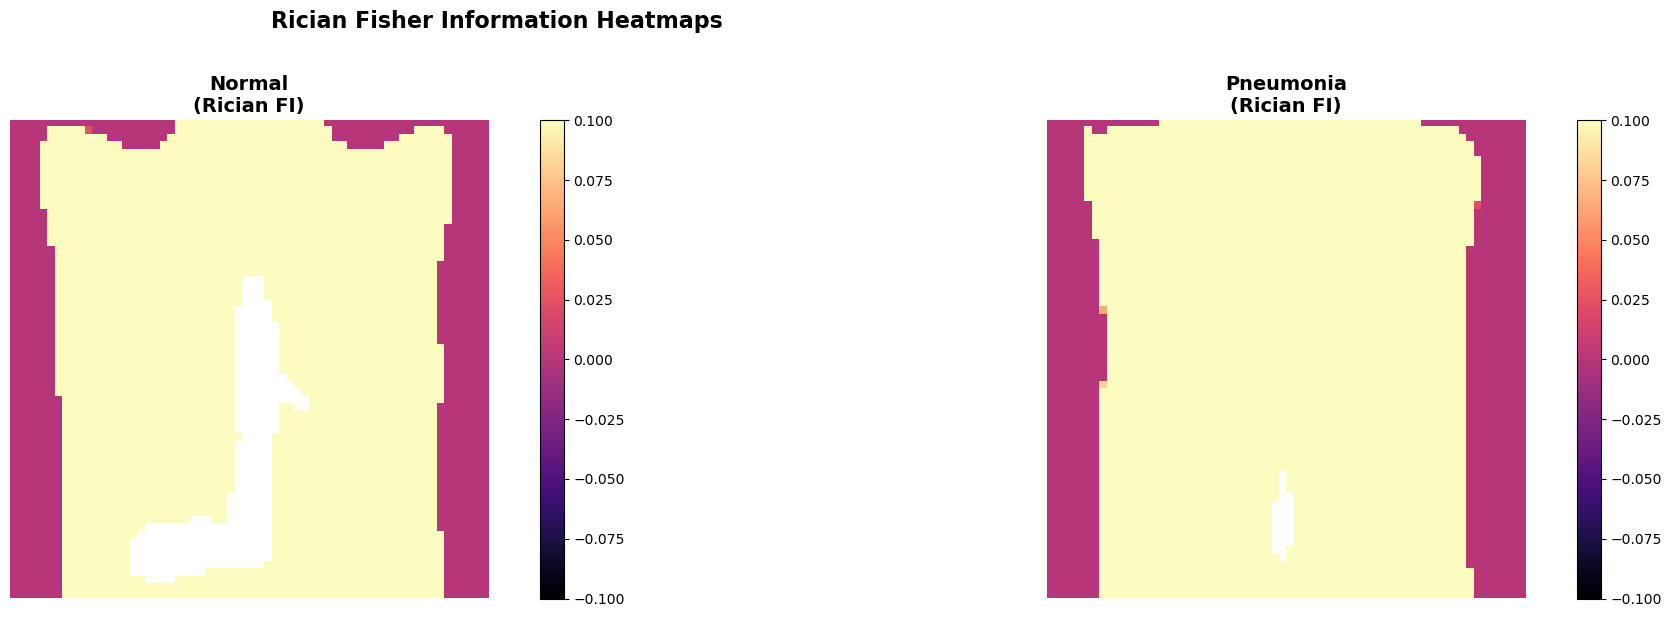

In [3]:
import numpy as np
from scipy.special import i0, i1
from scipy.integrate import quad

def estimate_rician_params(pixel_values):
    """
    Estimates Rician parameters A (true signal) and sigma (noise std)
    from observed pixel magnitudes using method of moments.
    
    For Rician distribution:
        E[M^2] = A^2 + 2*sigma^2
        Var[M] = E[M^2] - E[M]^2
    
    We solve:
        sigma^2 = (E[M^2] - E[M]^2) / (2 - pi/2)   [approx]
        A^2     = E[M^2] - 2*sigma^2
    
    Parameters
    ----------
    pixel_values : 1D array of shape (N_samples,)
        Observed pixel intensities at one spatial location across N images
    
    Returns
    -------
    A     : float — estimated true signal amplitude
    sigma : float — estimated noise standard deviation
    """
    m1  = np.mean(pixel_values)           # E[M]
    m2  = np.mean(pixel_values**2)        # E[M^2] = A^2 + 2*sigma^2
    var = np.var(pixel_values)            # Var[M]

    # Method of moments approximation
    # Var[M] ≈ sigma^2 * (2 - pi/2) at high SNR
    # More robust: use E[M^2] directly
    sigma2 = np.clip(var / (2 - np.pi/2 + 1e-8), 1e-8, None)
    A2     = np.clip(m2 - 2*sigma2, 0, None)   # A^2 must be non-negative

    return np.sqrt(A2), np.sqrt(sigma2)


def rician_fi_single_pixel(A, sigma, n_quad=200):
    """
    Computes the exact Fisher Information I(A) for a single pixel
    under the Rician distribution via numerical integration.
    
    I(A) = -E[d^2 ln p / dA^2]
         = integral over M of: p(M|A) * [-d^2 ln p/dA^2] dM
    
    The second derivative of log-likelihood:
    
    d ln p / dA   = -A/sigma^2 + (M/sigma^2) * I1(MA/sigma^2)/I0(MA/sigma^2)
    
    d^2 ln p/dA^2 = -1/sigma^2 
                    + (M/sigma^2)^2 * d/dx[I1(x)/I0(x)]|_{x=MA/sigma^2}
    
    where d/dx[I1(x)/I0(x)] = 1 - (I1(x)/I0(x))^2 - (I1(x)/I0(x))/x
    
    Parameters
    ----------
    A     : float — true signal amplitude
    sigma : float — noise standard deviation
    n_quad : int  — number of quadrature points
    
    Returns
    -------
    fi : float — Fisher Information at this pixel
    """
    if sigma < 1e-8:
        return 0.0

    def integrand(M):
        if M <= 0:
            return 0.0

        s2  = sigma**2
        x   = M * A / s2      # argument of Bessel functions

        # Rician PDF
        pdf = (M / s2) * np.exp(-(M**2 + A**2) / (2*s2)) * i0(x)

        if pdf < 1e-300:
            return 0.0

        # Ratio I1(x)/I0(x) — bounded between 0 and 1
        ratio = i1(x) / (i0(x) + 1e-300)

        # d/dx [I1(x)/I0(x)] = 1 - ratio^2 - ratio/x
        # Handle x -> 0 limit: ratio -> x/2, so ratio/x -> 1/2
        if x > 1e-6:
            d_ratio = 1.0 - ratio**2 - ratio / x
        else:
            d_ratio = 0.5   # limit as x -> 0

        # Second derivative of log-likelihood
        d2_ll = -1.0/s2 + (M/s2)**2 * d_ratio

        # Contribution to FI = -E[d2_ll] = -p(M|A) * d2_ll
        return -pdf * d2_ll

    # Integration bounds: Rician is supported on [0, inf)
    # Upper bound: A + 8*sigma covers >99.999% of the distribution
    upper = max(A + 8*sigma, 8*sigma)

    fi, _ = quad(integrand, 0, upper, limit=n_quad)
    return max(fi, 0.0)   # FI must be non-negative


def compute_rician_fi_heatmap(image, class_images, epsilon=1e-8):
    """
    Computes the Fisher Information heatmap for a single image
    with respect to its class distribution, using the Rician PDF.
    
    For each pixel (i,j), estimates Rician parameters A and sigma
    from all training images of the same class, then computes
    the exact Rician FI via numerical integration.
    
    Parameters
    ----------
    image        : (H, W) array — the single query image (not used for 
                   parameter estimation, only for spatial reference)
    class_images : (N, H, W) array — all training images of the same class
                   Used to estimate per-pixel Rician parameters
    epsilon      : float — numerical stability floor
    
    Returns
    -------
    fi_map : (H, W) array — Fisher Information at each pixel
    """
    H, W      = image.shape
    fi_map    = np.zeros((H, W), dtype=np.float32)

    for i in range(H):
        for j in range(W):
            pixel_vals = class_images[:, i, j]   # all observations at (i,j)
            A, sigma   = estimate_rician_params(pixel_vals)
            fi_map[i, j] = rician_fi_single_pixel(A, sigma)

        if i % 8 == 0:
            print(f'  Row {i}/{H}...', end='\r')

    print(f'  Done. FI map shape: {fi_map.shape}')
    return fi_map


def compute_rician_fi_all_classes(recon_images, y_train, dim=64):
    """
    Computes per-class Rician FI heatmaps across all 4 classes.
    
    Parameters
    ----------
    recon_images : (N, dim, dim) reconstructed proxy images
    y_train      : (N, 2) one-hot labels
    dim          : int — spatial dimension
    
    Returns
    -------
    fi_maps : dict of {class_name: (dim, dim) FI heatmap}
    """
    class_names = {0: 'Normal', 1: 'Pneumonia'}
    y_ints      = np.argmax(y_train, axis=1)
    fi_maps     = {}

    for c in range(2):
        print(f'\nComputing Rician FI for class: {class_names[c]}')
        class_imgs = recon_images[y_ints == c]   # (N_c, dim, dim)

        # Use the mean image of the class as the reference image
        ref_image  = np.mean(class_imgs, axis=0)

        fi_maps[class_names[c]] = compute_rician_fi_heatmap(
            ref_image, class_imgs
        )

    return fi_maps


# ── Run it ────────────────────────────────────────────────────────────────────
fi_maps_rician = compute_rician_fi_all_classes(
    x_train.reshape(x_train.shape[0], 64, 64), y_train
)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
order       = ['Normal', 'Pneumonia']  # Adjust based on your actual class names
all_vals    = np.concatenate([fi_maps_rician[c].flatten() for c in order])
global_vmax = np.percentile(all_vals, 99)

for idx, cls in enumerate(order):
    im = axes[idx].imshow(fi_maps_rician[cls], cmap='magma',
                          vmin=0, vmax=global_vmax)
    axes[idx].set_title(f'{cls}\n(Rician FI)', fontsize=14, fontweight='bold')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Rician Fisher Information Heatmaps', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rician_fi_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
def estimate_sigma_from_image(image, percentile=10):
    """
    Estimates Rician noise sigma from a single image using the
    low-intensity background region.
    
    In MRI, background pixels (no signal) follow a Rayleigh distribution
    with parameter sigma. For Rayleigh: E[M] = sigma * sqrt(pi/2)
    So: sigma = E[M_background] / sqrt(pi/2)
    
    Parameters
    ----------
    image      : (H, W) single image
    percentile : float — pixels below this intensity percentile 
                 are treated as background
    
    Returns
    -------
    sigma : float — estimated noise standard deviation
    """
    threshold        = np.percentile(image, percentile)
    background_pixels = image[image <= threshold]
    
    if len(background_pixels) < 10:
        # Fallback: use global std
        return np.std(image) / np.sqrt(2)
    
    # Rayleigh estimator: sigma = mean / sqrt(pi/2)
    sigma = np.mean(background_pixels) / np.sqrt(np.pi / 2)
    return max(sigma, 1e-8)


def compute_single_pair_fi_heatmap(image1, image2, n_jobs=-1):
    """
    Computes the pairwise Rician Fisher Information heatmap between
    two individual images from different classes.

    For each pixel (i,j):

        A1    = image1(i,j)   — single observation, treated as amplitude estimate
        A2    = image2(i,j)   — single observation, treated as amplitude estimate
        sigma = estimated globally from each image separately

        FI(i,j) = (A1 - A2)^2 / (1/I(A1,sigma) + 1/I(A2,sigma))

    Parameters
    ----------
    image1 : (H, W) array — single image from class 1
    image2 : (H, W) array — single image from class 2
    n_jobs : int — parallel jobs (-1 = all cores)

    Returns
    -------
    fi_map : (H, W) pairwise FI heatmap
    """
    from joblib import Parallel, delayed

    H, W = image1.shape

    # Estimate sigma globally from each image
    sigma1 = estimate_sigma_from_image(image1)
    sigma2 = estimate_sigma_from_image(image2)
    sigma  = (sigma1 + sigma2) / 2.0  # pooled noise estimate

    print(f'Estimated sigma: {sigma:.6f} (img1={sigma1:.6f}, img2={sigma2:.6f})')

    def process_pixel(i, j):
        A1 = float(image1[i, j])
        A2 = float(image2[i, j])

        # Exact Rician FI at each pixel amplitude
        fi1 = rician_fi_single_pixel(A1, sigma)
        fi2 = rician_fi_single_pixel(A2, sigma)

        numerator   = (A1 - A2)**2
        denominator = (1.0 / (fi1 + 1e-10)) + (1.0 / (fi2 + 1e-10))

        return i, j, numerator / (denominator + 1e-10)

    print(f'Computing single-pair Rician FI on {H}x{W} grid...')
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(process_pixel)(i, j)
        for i in range(H) for j in range(W)
    )

    fi_map = np.zeros((H, W), dtype=np.float32)
    for i, j, val in results:
        fi_map[i, j] = val

    return fi_map


def visualise_single_pair_fi(image1, image2, fi_map,
                              class1_name='Class 1',
                              class2_name='Class 2'):
    """
    Visualises the two input images alongside their pairwise FI heatmap.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(f'{class1_name}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(f'{class2_name}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    vmax = np.percentile(fi_map, 99)
    im   = axes[2].imshow(fi_map, cmap='magma', vmin=0, vmax=vmax)
    axes[2].set_title(f'Rician FI\n{class1_name} vs {class2_name}',
                      fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle('Single-Pair Rician Fisher Information Heatmap',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('single_pair_rician_fi.png', dpi=300, bbox_inches='tight')
    plt.show()

Estimated sigma: 0.097120 (img1=0.048014, img2=0.146226)
Computing single-pair Rician FI on 64x64 grid...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 2798 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 4096 out of 4096 | elapsed:    2.0s finished


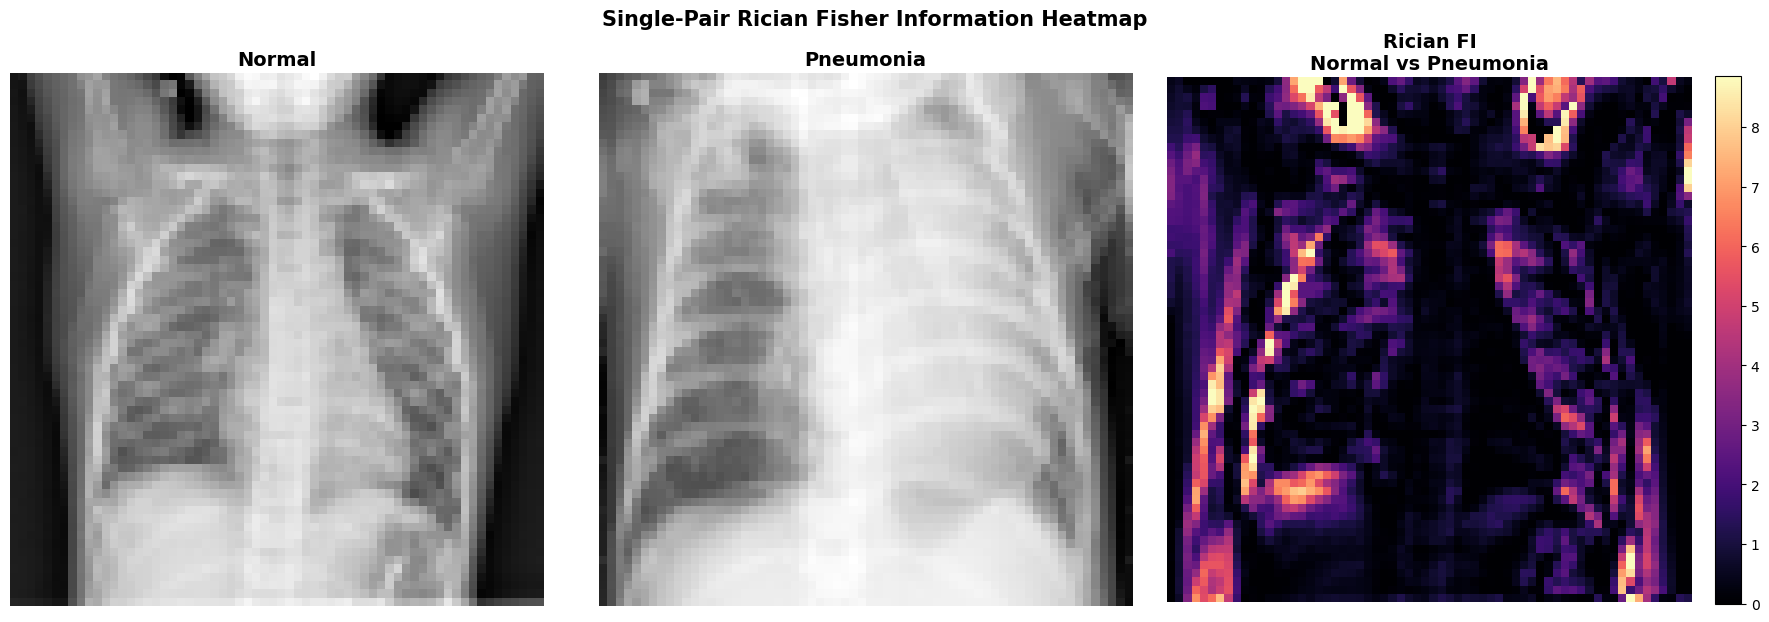

In [5]:
fi = compute_single_pair_fi_heatmap(x_train[0], x_train[3000])

visualise_single_pair_fi(x_train[0], x_train[3000], fi,
                          class1_name='Normal', class2_name='Pneumonia')

In [6]:
normal = []
pneumonia = []

for i in y_train:
    if i[0] == 1:
        normal.append(i)
    else:
        pneumonia.append(i)

print(len(normal), len(pneumonia))

1341 3875


In [13]:
i = 0

while y_train[i][0] == 1.0:
    i += 1

print(i)

1341


In [22]:
import numpy as np

N_PAIRS     = 10000
N_NORMAL    = 1341   # indices 0 to 1340
N_PNEUMONIA = 3875   # indices 1341 to 5215

rng = np.random.default_rng(seed=42)

# Normal: sample from [0, 1340]
# Pneumonia: sample from [1341, 5215]
normal_indices    = rng.integers(0,    N_NORMAL,              size=N_PAIRS)
pneumonia_indices = rng.integers(N_NORMAL, N_NORMAL + N_PNEUMONIA, size=N_PAIRS)

# Verify
assert normal_indices.min() >= 0
assert normal_indices.max() <= 1340
assert pneumonia_indices.min() >= 1341
assert pneumonia_indices.max() <= 5215

print(f'Normal    — min: {normal_indices.min()}, max: {normal_indices.max()}')
print(f'Pneumonia — min: {pneumonia_indices.min()}, max: {pneumonia_indices.max()}')

# Stack into a single (10000, 2) array for convenience
pairs = np.stack([normal_indices, pneumonia_indices], axis=1)
print(f'\nPairs shape: {pairs.shape}')

Normal    — min: 0, max: 1340
Pneumonia — min: 1342, max: 5215

Pairs shape: (10000, 2)


In [ ]:
import numpy as np

DIM     = 64
N_PAIRS = 10000

# Preallocate — much faster than appending
# Shape: (10000, 64, 64)
fi_diff_maps = np.zeros((N_PAIRS, DIM, DIM), dtype=np.float32)

for k in range(N_PAIRS):
    img_normal    = x_train[pairs[k, 0]]
    img_pneumonia = x_train[pairs[k, 1]]
    
    fi_diff_maps[k] = compute_single_pair_fi_heatmap(
        img_normal, img_pneumonia
    )
    
    if k % 500 == 0:
        print(f'{k}/{N_PAIRS} done...')

print(f'Done. fi_diff_maps shape: {fi_diff_maps.shape}')
print(f'Memory usage: {fi_diff_maps.nbytes / 1e6:.1f} MB')

Estimated sigma: 0.043733 (img1=0.079149, img2=0.008317)
Computing single-pair Rician FI on 64x64 grid...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 216 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 2682 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 4096 out of 4096 | elapsed:    2.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.1s


0/10000 done...
Estimated sigma: 0.043514 (img1=0.086367, img2=0.000660)
Computing single-pair Rician FI on 64x64 grid...


[Parallel(n_jobs=-1)]: Done 512 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4096 out of 4096 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.1s


Estimated sigma: 0.057643 (img1=0.039161, img2=0.076125)
Computing single-pair Rician FI on 64x64 grid...


...

Estimated sigma: 0.006201 (img1=0.011751, img2=0.000652)
Computing single-pair Rician FI on 64x64 grid...


/tmp/ipykernel_3004/1672165537.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
/tmp/ipykernel_3004/1672165537.py:79: RuntimeWarning: invalid value encountered in scalar multiply
/tmp/ipykernel_3004/1672165537.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
/tmp/ipykernel_3004/1672165537.py:85: RuntimeWarning: invalid value encountered in scalar divide
/tmp/ipykernel_3004/1672165537.py:79: RuntimeWarning: invalid value encountered in scalar multiply
/tmp/ipykernel_3004/1672165537.py:85: RuntimeWarning: invalid value encountered in scalar divide
/tmp/ipykernel_3004/1672165537.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underesti

Estimated sigma: 0.044370 (img1=0.035866, img2=0.052873)
Computing single-pair Rician FI on 64x64 grid...


[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 512 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4096 out of 4096 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.1s


Estimated sigma: 0.081632 (img1=0.024888, img2=0.138375)
Computing single-pair Rician FI on 64x64 grid...
